# Lab 4: Two-Body Collisions

Name: Aidan Siddiqi
Date: 9/20/2026
Lab: PHYS 311 Module 4

This notebook builds a 1D and 2D collision engine using the restitution formulas from the Week 4 lesson, then tests it in a box with two balls and finally a many-body gas.

**AI use disclaimer:** AI (Claude) was used in preparing this notebook for coding assistance, tidying up code, and improving code flow/organization. This is not to say that there was no human work done in this code; all lines included input and assistance from myself and many iterations and human attempts are consolidated into the notebook seen below.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Part A: 1D Collisions with Restitution

We use the coefficient-of-restitution formula from the lesson. It covers elastic, inelastic, and perfectly inelastic collisions with one function.

In [2]:
def collide_1d(m1, m2, u1, u2, e=1.0):
    total_m = m1 + m2
    v_cm = (m1 * u1 + m2 * u2) / total_m
    v1 = v_cm - e * (m2 / total_m) * (u1 - u2)
    v2 = v_cm + e * (m1 / total_m) * (u1 - u2)
    return v1, v2

First we check the three limiting cases with e = 1.

In [3]:
v1, v2 = collide_1d(1.0, 1.0, 3.0, 0.0, e=1.0)
print(f"Equal masses: v1 = {v1:.3f}, v2 = {v2:.3f} (should swap to 0, 3)")

v1, v2 = collide_1d(0.1, 100.0, 5.0, 0.0, e=1.0)
print(f"Light hits heavy: v1 = {v1:.3f}, v2 = {v2:.3f} (light ball should nearly reverse)")

v1, v2 = collide_1d(100.0, 0.1, 5.0, 0.0, e=1.0)
print(f"Heavy hits light: v1 = {v1:.3f}, v2 = {v2:.3f} (heavy barely slows, light flies off near 2x)")

Equal masses: v1 = 0.000, v2 = 3.000 (should swap to 0, 3)
Light hits heavy: v1 = -4.990, v2 = 0.010 (light ball should nearly reverse)
Heavy hits light: v1 = 4.990, v2 = 9.990 (heavy barely slows, light flies off near 2x)


All three match what the lesson says to expect. Equal masses swap velocities. The light ball reverses almost completely. The heavy ball barely slows, and the light ball flies off at close to twice the incoming speed.

Now the conservation table: a 2 kg block at 4 m/s hits a stationary 3 kg block.

In [4]:
m1, m2, u1, u2 = 2.0, 3.0, 4.0, 0.0
p_before = m1 * u1 + m2 * u2
ke_before = 0.5 * m1 * u1**2 + 0.5 * m2 * u2**2

print(f"Before: p = {p_before:.2f}, KE = {ke_before:.2f}")
print()

for e in [1.0, 0.5, 0.0]:
    v1, v2 = collide_1d(m1, m2, u1, u2, e)
    p_after = m1 * v1 + m2 * v2
    ke_after = 0.5 * m1 * v1**2 + 0.5 * m2 * v2**2
    print(f"e = {e}: v1 = {v1:.2f}, v2 = {v2:.2f}, p_after = {p_after:.2f}, KE_after = {ke_after:.2f}")

Before: p = 8.00, KE = 16.00

e = 1.0: v1 = -0.80, v2 = 3.20, p_after = 8.00, KE_after = 16.00
e = 0.5: v1 = 0.40, v2 = 2.40, p_after = 8.00, KE_after = 8.80
e = 0.0: v1 = 1.60, v2 = 1.60, p_after = 8.00, KE_after = 6.40


| e | v1 (m/s) | v2 (m/s) | Momentum after | KE after |
|---|---|---|---|---|
| 1.0 | -0.80 | 3.20 | 8.00 | 16.00 |
| 0.5 | 0.40 | 2.40 | 8.00 | 8.80 |
| 0.0 | 1.60 | 1.60 | 8.00 | 6.40 |

Momentum before was also 8.00, and KE before was 16.00.

Momentum is exactly 8.00 in every case. KE drops from 16.00 to 8.80 to 6.40 as e goes from 1 to 0.5 to 0. The missing KE does not disappear. It turns into heat, sound, and permanent deformation of the two blocks at the point of contact. Momentum has nowhere to hide, since it is a vector shared by the whole system. KE can leak into these other forms, which is why it is not the reliable conservation law here.

## Part B: 2D Collisions in a Box

Now we give the balls an x and a y. Two balls move inside a box, bounce off the walls, and collide with each other. We store each ball as a dictionary with mass, position, velocity, and radius, and keep them in a list.

In [5]:
def collide_2d(m1, m2, r1, r2, v1, v2, e=1.0):
    r1, r2 = np.asarray(r1, float), np.asarray(r2, float)
    v1, v2 = np.asarray(v1, float), np.asarray(v2, float)

    n = r2 - r1
    dist = np.linalg.norm(n)
    if dist == 0:
        return v1, v2
    n = n / dist

    u1n, u2n = np.dot(v1, n), np.dot(v2, n)
    v1t = v1 - u1n * n
    v2t = v2 - u2n * n

    new1n, new2n = collide_1d(m1, m2, u1n, u2n, e)

    return v1t + new1n * n, v2t + new2n * n

def overlapping(r1, r2, radius1, radius2):
    return np.linalg.norm(np.asarray(r2) - np.asarray(r1)) < (radius1 + radius2)

In [6]:
W, H = 10.0, 6.0
dt = 0.01
n_steps = 450

bodies = [
    {'m': 2.0, 'r': np.array([1.0, 3.0]), 'v': np.array([2.0, 0.0]), 'radius': 0.3},
    {'m': 5.0, 'r': np.array([9.0, 3.4]), 'v': np.array([-1.0, 0.0]), 'radius': 0.5},
]

traj = [[], []]
px_hist, py_hist, ke_hist = [], [], []

for step in range(n_steps):
    for b in bodies:
        b['r'] = b['r'] + b['v'] * dt

    for b in bodies:
        if b['r'][0] - b['radius'] < 0 or b['r'][0] + b['radius'] > W:
            b['v'][0] = -b['v'][0]
            b['r'][0] = np.clip(b['r'][0], b['radius'], W - b['radius'])
        if b['r'][1] - b['radius'] < 0 or b['r'][1] + b['radius'] > H:
            b['v'][1] = -b['v'][1]
            b['r'][1] = np.clip(b['r'][1], b['radius'], H - b['radius'])

    b1, b2 = bodies
    approaching = np.dot(b2['v'] - b1['v'], b2['r'] - b1['r']) < 0
    if overlapping(b1['r'], b2['r'], b1['radius'], b2['radius']) and approaching:
        b1['v'], b2['v'] = collide_2d(b1['m'], b2['m'], b1['r'], b2['r'], b1['v'], b2['v'], e=1.0)

    for i, b in enumerate(bodies):
        traj[i].append(b['r'].copy())

    p = sum(b['m'] * b['v'] for b in bodies)
    ke = sum(0.5 * b['m'] * np.dot(b['v'], b['v']) for b in bodies)
    px_hist.append(p[0])
    py_hist.append(p[1])
    ke_hist.append(ke)

traj = [np.array(t) for t in traj]

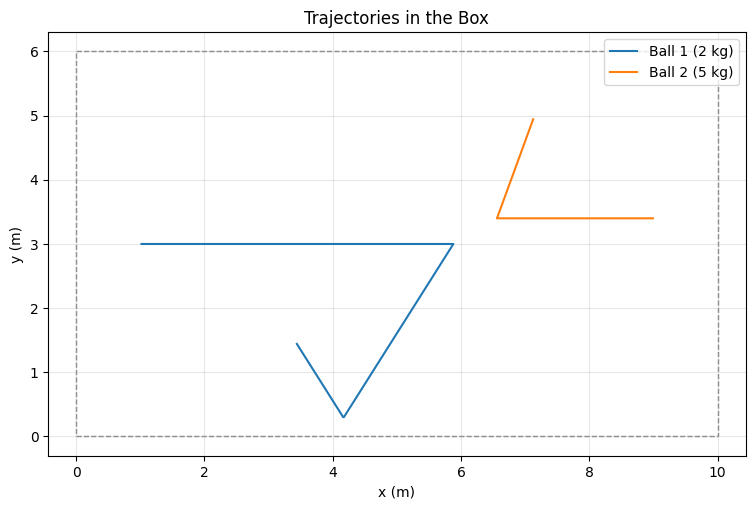

In [7]:
plt.figure(figsize=(9, 5.5))
plt.plot(traj[0][:, 0], traj[0][:, 1], label='Ball 1 (2 kg)')
plt.plot(traj[1][:, 0], traj[1][:, 1], label='Ball 2 (5 kg)')
plt.gca().add_patch(plt.Rectangle((0, 0), W, H, fill=False, linestyle='--', color='gray'))
plt.xlabel('x (m)')
plt.ylabel('y (m)')
plt.title('Trajectories in the Box')
plt.legend()
plt.axis('equal')
plt.grid(alpha=0.3)
plt.show()

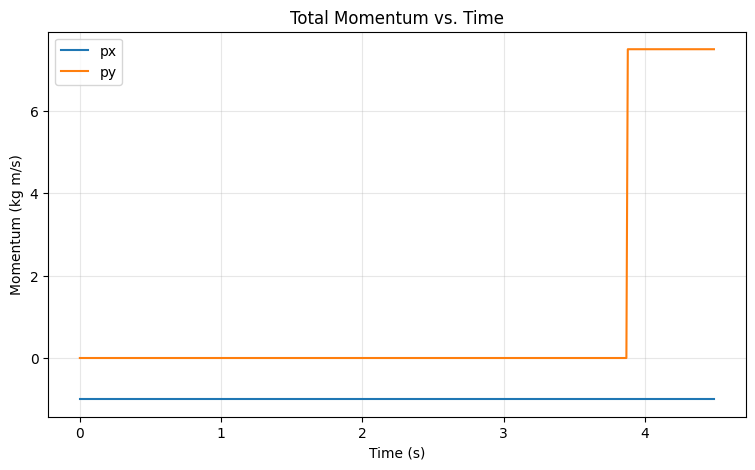

In [8]:
t_arr = np.arange(n_steps) * dt

plt.figure(figsize=(9, 5))
plt.plot(t_arr, px_hist, label='px')
plt.plot(t_arr, py_hist, label='py')
plt.xlabel('Time (s)')
plt.ylabel('Momentum (kg m/s)')
plt.title('Total Momentum vs. Time')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

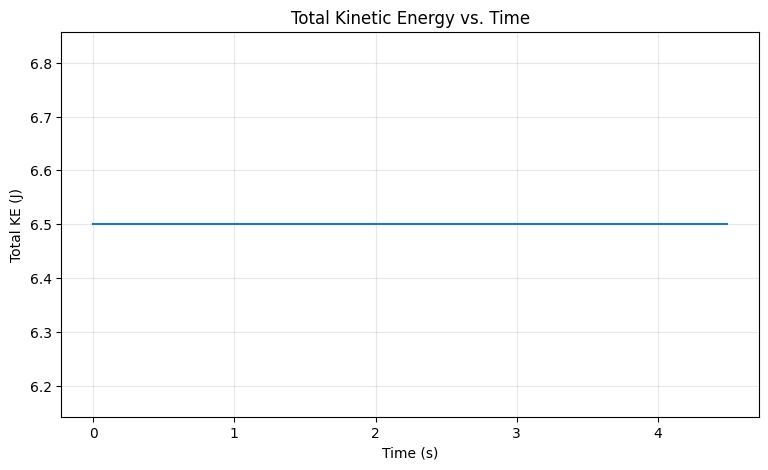

KE min = 6.500000, KE max = 6.500000


In [9]:
plt.figure(figsize=(9, 5))
plt.plot(t_arr, ke_hist)
plt.xlabel('Time (s)')
plt.ylabel('Total KE (J)')
plt.title('Total Kinetic Energy vs. Time')
plt.grid(alpha=0.3)
plt.show()

print(f"KE min = {min(ke_hist):.6f}, KE max = {max(ke_hist):.6f}")

With elastic collisions and elastic walls, total KE should stay exactly constant. It does. The ball-ball collision does not change speed at e = 1, and a wall bounce only flips one velocity component, so it does not change speed either.

Momentumstays flat through the ball-ball collision, since that collision conserves momentum. It jumps sharply the moment one ball hits a wall. The wall is not part of our system. It is an external object that pushes back on the ball without anything pushing back on it in return. That push is an external force, so it is exactly the case where momentum conservation is not supposed to hold.

## Part C: Inelastic Collisions & Energy Accounting

Now we sweep e and watch where the missing energy goes.

In [10]:
def simulate_box(e, n_steps=450, W=10.0, H=6.0, dt=0.01):
    bodies = [
        {'m': 2.0, 'r': np.array([1.0, 3.0]), 'v': np.array([2.0, 0.0]), 'radius': 0.3},
        {'m': 5.0, 'r': np.array([9.0, 3.4]), 'v': np.array([-1.0, 0.0]), 'radius': 0.5},
    ]
    ke_hist = []
    first_collision = None

    for step in range(n_steps):
        for b in bodies:
            b['r'] = b['r'] + b['v'] * dt

        for b in bodies:
            if b['r'][0] - b['radius'] < 0 or b['r'][0] + b['radius'] > W:
                b['v'][0] = -b['v'][0]
                b['r'][0] = np.clip(b['r'][0], b['radius'], W - b['radius'])
            if b['r'][1] - b['radius'] < 0 or b['r'][1] + b['radius'] > H:
                b['v'][1] = -b['v'][1]
                b['r'][1] = np.clip(b['r'][1], b['radius'], H - b['radius'])

        b1, b2 = bodies
        approaching = np.dot(b2['v'] - b1['v'], b2['r'] - b1['r']) < 0
        ke_before_step = sum(0.5 * b['m'] * np.dot(b['v'], b['v']) for b in bodies)

        if overlapping(b1['r'], b2['r'], b1['radius'], b2['radius']) and approaching:
            if first_collision is None:
                n = (b2['r'] - b1['r']) / np.linalg.norm(b2['r'] - b1['r'])
                u1n, u2n = np.dot(b1['v'], n), np.dot(b2['v'], n)
            b1['v'], b2['v'] = collide_2d(b1['m'], b2['m'], b1['r'], b2['r'], b1['v'], b2['v'], e)
            ke_after_step = sum(0.5 * b['m'] * np.dot(b['v'], b['v']) for b in bodies)
            if first_collision is None:
                first_collision = (ke_before_step, ke_after_step, u1n, u2n)

        ke_hist.append(sum(0.5 * b['m'] * np.dot(b['v'], b['v']) for b in bodies))

    return np.array(ke_hist), first_collision

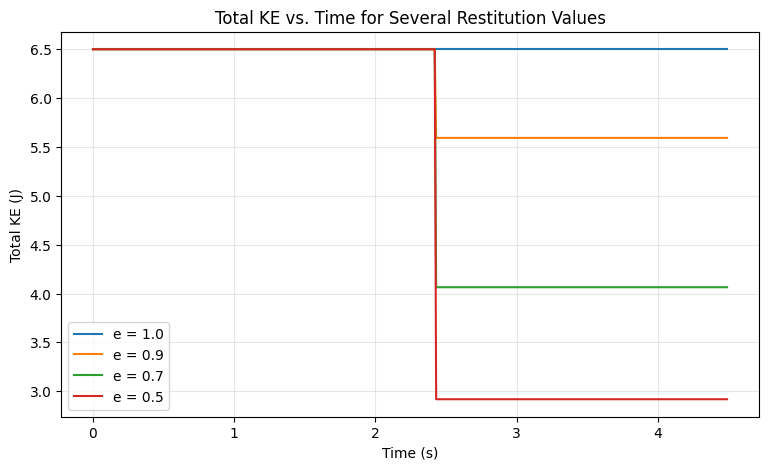

In [11]:
e_values = [1.0, 0.9, 0.7, 0.5]

plt.figure(figsize=(9, 5))
for e in e_values:
    ke_hist, _ = simulate_box(e)
    t_arr = np.arange(len(ke_hist)) * 0.01
    plt.plot(t_arr, ke_hist, label=f"e = {e}")
plt.xlabel('Time (s)')
plt.ylabel('Total KE (J)')
plt.title('Total KE vs. Time for Several Restitution Values')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [12]:
m1, m2 = 2.0, 5.0
mu = m1 * m2 / (m1 + m2)

print(f"{'e':<6}{'KE lost (sim)':<18}{'KE lost (theory)':<18}")
for e in e_values:
    ke_hist, first_collision = simulate_box(e)
    ke_before, ke_after, u1n, u2n = first_collision
    frac_sim = (ke_before - ke_after) / ke_before

    u_rel = u1n - u2n
    theory_loss = 0.5 * mu * u_rel**2 * (1 - e**2)
    frac_theory = theory_loss / ke_before

    print(f"{e:<6}{frac_sim*100:<18.2f}{frac_theory*100:<18.2f}")

e     KE lost (sim)     KE lost (theory)  
1.0   -0.00             0.00              
0.9   13.96             13.96             
0.7   37.47             37.47             
0.5   55.11             55.11             


The simulated fraction lost matches the theoretical head-on prediction almost exactly for every e. That is expected, since the collision code applies the restitution condition only to the normal component of the relative velocity, which is exactly what the theory formula assumes.

Next, the center-of-mass test. We remove the walls and let the balls fly apart after colliding.

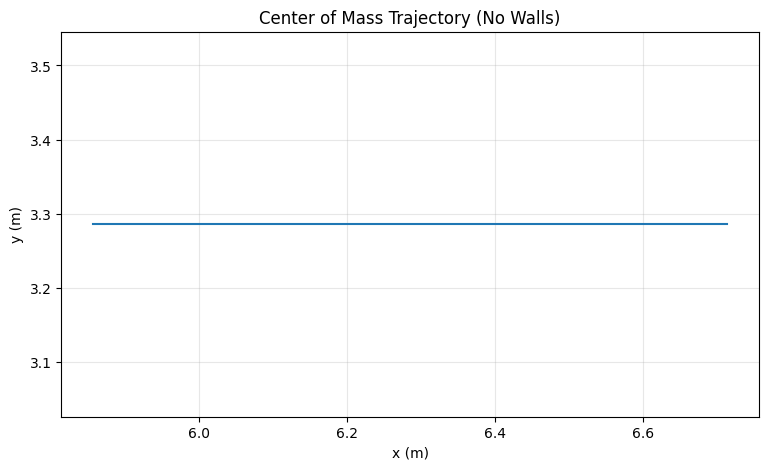

In [13]:
bodies = [
    {'m': 2.0, 'r': np.array([1.0, 3.0]), 'v': np.array([2.0, 0.0]), 'radius': 0.3},
    {'m': 5.0, 'r': np.array([9.0, 3.4]), 'v': np.array([-1.0, 0.0]), 'radius': 0.5},
]
M_total = bodies[0]['m'] + bodies[1]['m']
n_steps_cm = 600
dt = 0.01

cm_hist = []
for step in range(n_steps_cm):
    for b in bodies:
        b['r'] = b['r'] + b['v'] * dt

    b1, b2 = bodies
    approaching = np.dot(b2['v'] - b1['v'], b2['r'] - b1['r']) < 0
    if overlapping(b1['r'], b2['r'], b1['radius'], b2['radius']) and approaching:
        b1['v'], b2['v'] = collide_2d(b1['m'], b2['m'], b1['r'], b2['r'], b1['v'], b2['v'], e=1.0)

    R_cm = (b1['m'] * b1['r'] + b2['m'] * b2['r']) / M_total
    cm_hist.append(R_cm.copy())

cm_hist = np.array(cm_hist)

plt.figure(figsize=(9, 5))
plt.plot(cm_hist[:, 0], cm_hist[:, 1])
plt.xlabel('x (m)')
plt.ylabel('y (m)')
plt.title('Center of Mass Trajectory (No Walls)')
plt.axis('equal')
plt.grid(alpha=0.3)
plt.show()

The center of mass traces a single straight line, with no kink where the collision happens. Momentum conservation guarantees this no matter how the two balls bounce off each other. This is a powerful check because it does not depend on knowing the correct post-collision velocities ahead of time. A bend in the line would mean momentum was not conserved, which would mean a bug in the collision code.

**Analysis.** For e < 1, total KE should never increase at any single step. A collision at e < 1 can only remove kinetic energy or leave it unchanged at e = 1. Between collisions, with no forces acting, KE cannot change either. If KE ever moevd upward, that would mean the collision code was adding energy from nowhere, which is not physically possible for e ≤ 1.

This test works even without knowing the exact answer ahead of time. We do not need to know how much energy a real collision should remove. We only need the one-way rule that it can never add energy. That rule alone is enough to catch a bug, the same way an energy plot that only ever grows was enough to catch standard Euler's problem back in Lab 2.

## Bonus: Gas in a Box

We scale up to many balls, all starting with the same speed but random directions, and let them collide elastically.

In [14]:
np.random.seed(42)
N = 40
W, H = 10.0, 10.0
radius = 0.15
v0 = 2.0

positions = []
attempts = 0
while len(positions) < N and attempts < 20000:
    p = np.random.uniform(radius, [W - radius, H - radius])
    if all(np.linalg.norm(p - q) >= 2 * radius + 0.05 for q in positions):
        positions.append(p)
    attempts += 1

angles = np.random.uniform(0, 2 * np.pi, N)
bodies = [
    {'m': 1.0, 'r': np.array(positions[i]), 'v': v0 * np.array([np.cos(angles[i]), np.sin(angles[i])]), 'radius': radius}
    for i in range(N)
]

speeds_initial = np.array([np.linalg.norm(b['v']) for b in bodies])

In [15]:
dt = 0.01
n_steps = 4000

ke_hist, px_hist, py_hist = [], [], []

for step in range(n_steps):
    for b in bodies:
        b['r'] = b['r'] + b['v'] * dt

    for b in bodies:
        if b['r'][0] - b['radius'] < 0 or b['r'][0] + b['radius'] > W:
            b['v'][0] = -b['v'][0]
            b['r'][0] = np.clip(b['r'][0], b['radius'], W - b['radius'])
        if b['r'][1] - b['radius'] < 0 or b['r'][1] + b['radius'] > H:
            b['v'][1] = -b['v'][1]
            b['r'][1] = np.clip(b['r'][1], b['radius'], H - b['radius'])

    for i in range(N):
        for j in range(i + 1, N):
            bi, bj = bodies[i], bodies[j]
            approaching = np.dot(bj['v'] - bi['v'], bj['r'] - bi['r']) < 0
            if overlapping(bi['r'], bj['r'], bi['radius'], bj['radius']) and approaching:
                bi['v'], bj['v'] = collide_2d(bi['m'], bj['m'], bi['r'], bj['r'], bi['v'], bj['v'], e=1.0)

    ke_hist.append(sum(0.5 * b['m'] * np.dot(b['v'], b['v']) for b in bodies))
    p = sum(b['m'] * b['v'] for b in bodies)
    px_hist.append(p[0])
    py_hist.append(p[1])

speeds_final = np.array([np.linalg.norm(b['v']) for b in bodies])

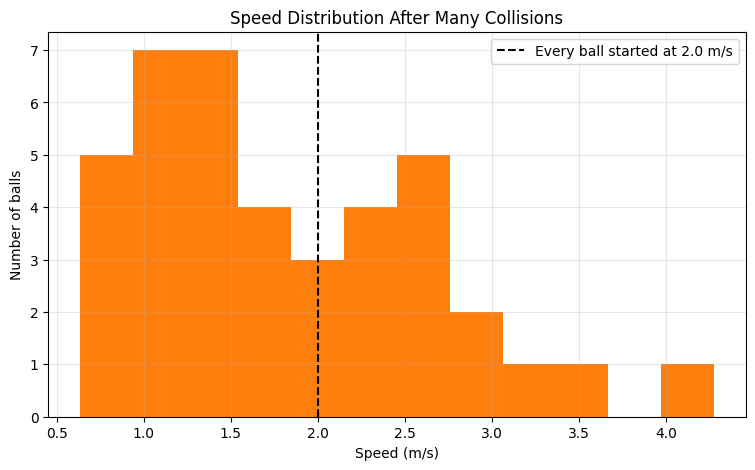

In [16]:
plt.figure(figsize=(9, 5))
plt.hist(speeds_final, bins=12, color='tab:orange')
plt.axvline(v0, color='black', linestyle='--', label=f'Every ball started at {v0} m/s')
plt.xlabel('Speed (m/s)')
plt.ylabel('Number of balls')
plt.title('Speed Distribution After Many Collisions')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [17]:
print(f"KE initial = {ke_hist[0]:.4f}, KE final = {ke_hist[-1]:.4f}")
print(f"px initial = {px_hist[0]:.4f}, px final = {px_hist[-1]:.4f}")
print(f"py initial = {py_hist[0]:.4f}, py final = {py_hist[-1]:.4f}")

KE initial = 80.0000, KE final = 80.0000
px initial = 4.6101, px final = 8.6261
py initial = -4.8092, py final = 2.3654


KE stays essentially constant across the whole run. That is expected, since every collision is elastic and every wall bounce only flips a velocity component. Momentum is different again, as in Part B. With 40 balls bouncing off four walls thousands of times, there is no reason for total momentum to stay fixed, and it does not. Each wall hit is an external push on one ball, and none of those pushes cancel out over the whole run.

Every ball started at the same speed. By the end, the speeds are spread out from below 1 m/s to well above 4 m/s. Repeated random collisions constantly trade speed back and forth between whichever two balls happen to meet, so a single starting speed spreads into a range of speeds even though the total energy never changes. This is exactly how a real gas reaches a Maxwell-Boltzmann speed distribution; temperature describes the spread of molecular speeds, not one fixed speed for every molecule, and collisions are what generate that spread out of even a completely uniform start.